<a href="https://colab.research.google.com/github/hlmonge/HenryMonge_Examen_3/blob/main/CIFAR10_Clasificador_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificador de Imagenes - CIFAR-10
**Examen: Computacion en la Nube | UTH**

**Docente:** Ing. Asalia Zavala

In [ ]:
# PASO 1 - Instalar dependencias
!pip install tensorflow streamlit pillow -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 98.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 7.3 MB/s eta 0:00:00


In [ ]:
# PASO 2 - Cargar CIFAR-10 desde Keras (automatico, ~170MB)
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

CLASES = ['Avion', 'Auto', 'Pajaro', 'Gato', 'Ciervo',
          'Perro', 'Rana', 'Caballo', 'Barco', 'Camion']

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
print(f'Train: {x_train.shape} | Test: {x_test.shape}')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1003s 6us/step
Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)


In [ ]:
# PASO 3 - Definir modelo CNN
def build_model():
    m = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m

model = build_model()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 667,434 (2.55 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# PASO 4 - Entrenar RAPIDO (solo 5000 imagenes, 10 epocas)
from tensorflow.keras.callbacks import EarlyStopping

# Subset pequeño
x_tr = x_train[:5000]
y_tr = y_train[:5000]

history = model.fit(
    x_tr, y_tr,
    batch_size=64,
    epochs=10,
    validation_data=(x_test[:1000], y_test[:1000]),
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

loss, acc = model.evaluate(x_test[:1000], y_test[:1000], verbose=0)
print(f'Test Accuracy: {acc:.4f} ({acc*100:.1f}%)')

Epoch 1/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - accuracy: 0.7112 - loss: 0.8377 - val_accuracy: 0.7340 - val_loss: 0.7517
Epoch 2/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7250 - loss: 0.7854 - val_accuracy: 0.7050 - val_loss: 0.8709
Epoch 3/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7392 - loss: 0.7391 - val_accuracy: 0.7220 - val_loss: 0.8286
Epoch 4/10
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7512 - loss: 0.6962 - val_accuracy: 0.7050 - val_loss: 0.9057
Test Accuracy: 0.7340 (73.4%)


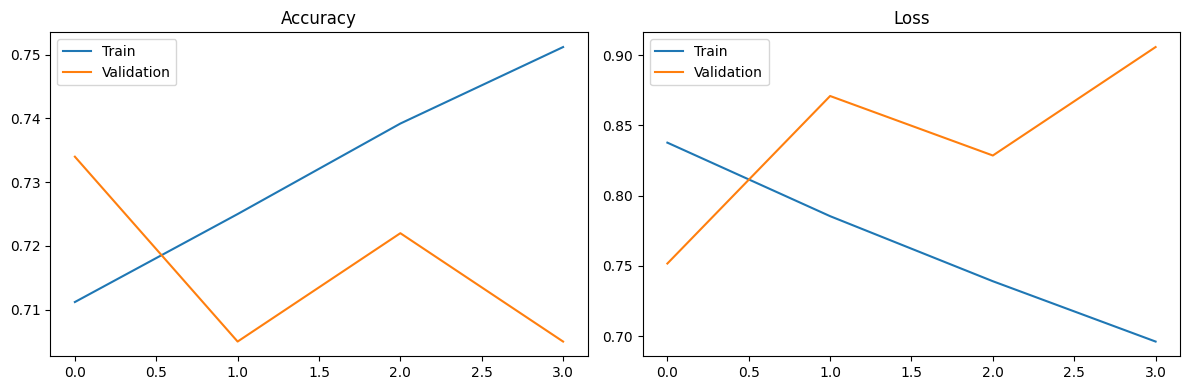

In [ ]:
# PASO 5 - Graficas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Accuracy'); ax1.legend()
ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Loss'); ax2.legend()
plt.tight_layout(); plt.show()

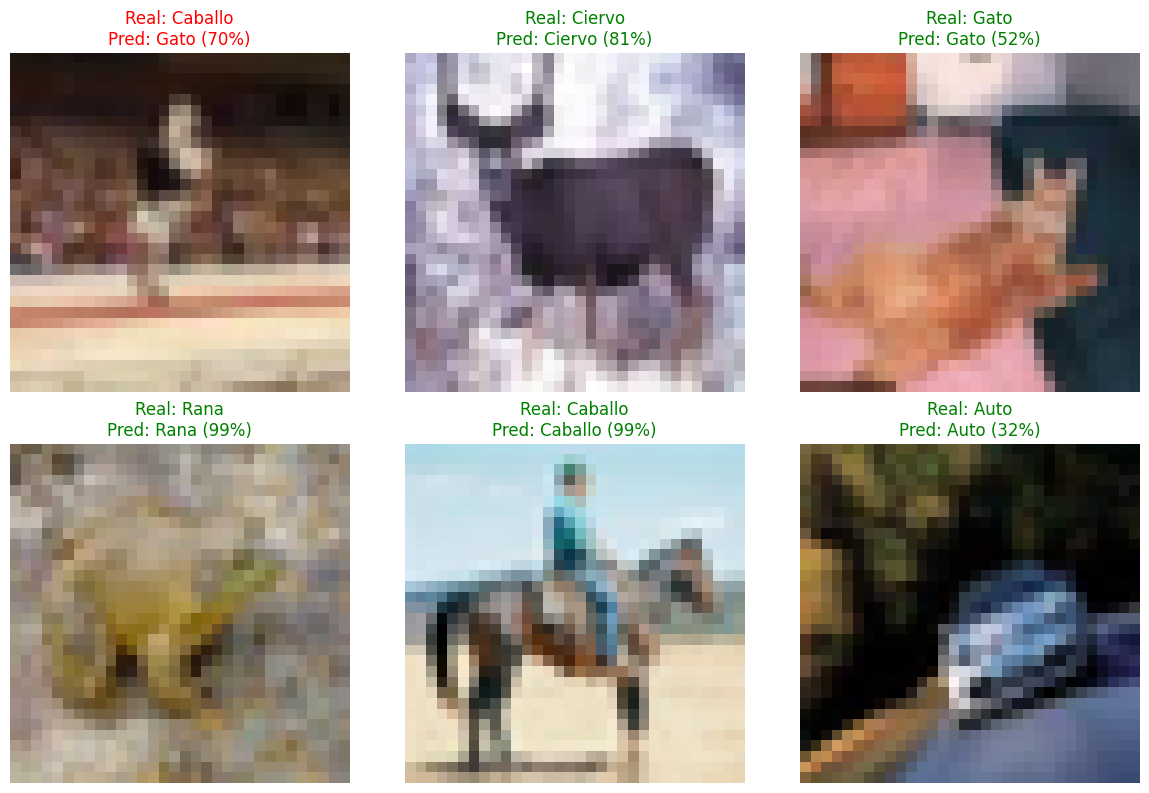

In [ ]:
# PASO 6 - Probar con 6 imagenes aleatorias del test set
indices = np.random.choice(len(x_test), 6, replace=False)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, idx in enumerate(indices):
    img = x_test[idx]
    real = CLASES[y_test[idx][0]]
    pred = model.predict(img[np.newaxis,...], verbose=0)
    clase_pred = CLASES[np.argmax(pred)]
    conf = np.max(pred)
    ax = axes[i//3][i%3]
    ax.imshow(img)
    color = 'green' if clase_pred == real else 'red'
    ax.set_title(f'Real: {real}\nPred: {clase_pred} ({conf:.0%})', color=color)
    ax.axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# PASO 7 - Guardar modelo (.keras y .h5)
model.save('cifar10_model.keras')
model.save('cifar10_model.h5')
print('Modelos guardados.')

from google.colab import files
files.download('cifar10_model.keras')

Modelos guardados.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# PASO 8 - Generar app.py para Streamlit
app_code = """import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

st.set_page_config(page_title='Clasificador | UTH', page_icon='*', layout='centered')

CLASES = ['Avion', 'Auto', 'Pajaro', 'Gato', 'Ciervo',
          'Perro', 'Rana', 'Caballo', 'Barco', 'Camion']

@st.cache_resource
def load_model():
    return tf.keras.models.load_model('cifar10_model.keras')

model = load_model()

st.title('Clasificador de Imagenes')
st.caption('Universidad Tecnologica de Honduras (UTH) | Computacion en la Nube')
st.divider()

fuente = st.radio('Fuente:', ['Subir archivo', 'Camara'], horizontal=True)
img_input = None

if fuente == 'Subir archivo':
    uploaded = st.file_uploader('Selecciona imagen', type=['jpg','jpeg','png','webp'])
    if uploaded:
        img_input = Image.open(uploaded).convert('RGB')
else:
    foto = st.camera_input('Tomar foto')
    if foto:
        img_input = Image.open(foto).convert('RGB')

if img_input:
    col1, col2 = st.columns(2)
    with col1:
        st.image(img_input, caption='Imagen cargada', use_column_width=True)
    with col2:
        img_r = img_input.resize((32, 32))
        arr = np.array(img_r).astype('float32') / 255.0
        arr = np.expand_dims(arr, 0)
        with st.spinner('Analizando...'):
            preds = model.predict(arr, verbose=0)[0]
        top_idx = np.argmax(preds)
        clase = CLASES[top_idx]
        conf = preds[top_idx]
        st.success('Resultado:')
        st.metric(clase, f'{conf:.1%}')
        st.write('Top 3:')
        for i in np.argsort(preds)[::-1][:3]:
            st.progress(float(preds[i]), text=f'{CLASES[i]}: {preds[i]:.1%}')

st.divider()
st.caption('Desarrollado por: [TU NOMBRE] | UTH | Dataset: CIFAR-10')
"""

with open('app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
print('app.py creado correctamente.')

app.py creado correctamente.


In [ ]:
# Guardar solo los pesos
model.save_weights('cifar10_weights.weights.h5')
from google.colab import files
files.download('cifar10_weights.weights.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Despliegue en Streamlit Cloud

1. Descargar `cifar10_model.keras` + `app.py`
2. Crear repo GitHub con esos archivos + `requirements.txt`
3. Ir a https://share.streamlit.io
4. New app -> seleccionar repo -> Main file: `app.py` -> Deploy
5. Copiar URL publica y entregar

**requirements.txt:**
```
tensorflow==2.15.0
streamlit==1.32.0
numpy==1.26.4
Pillow==10.2.0
```

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,001,408 (7.63 MB)

 Trainable params: 666,986 (2.54 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 1,333,974 (5.09 MB)